# WM-811K Wafer Map — Training Pipeline

Load the dataset, filter out unknown failure types, stratified 60/20/20 split, and build PyTorch `Dataset` / `DataLoader`.

In [1]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import zoom
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. Load the data

In [2]:
import pickle
import sys

# Patch old pandas module paths for compatibility
# The pickle was saved with pandas < 0.20 which used pandas.indexes.*
_compat_map = {
    'pandas.indexes':         'pandas.core.indexes',
    'pandas.indexes.base':    'pandas.core.indexes.base',
    'pandas.indexes.numeric': 'pandas.core.indexes.base',
    'pandas.indexes.range':   'pandas.core.indexes.range_',
    'pandas.indexes.multi':   'pandas.core.indexes.multi',
    'pandas.indexes.frozen':  'pandas.core.indexes.frozen',
}

for old, new in _compat_map.items():
    try:
        sys.modules[old] = __import__(new, fromlist=[''])
    except ImportError:
        pass

class _CompatUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        for old, new in _compat_map.items():
            if module.startswith(old):
                module = module.replace(old, new, 1)
                break
        return super().find_class(module, name)

with open("./Data/LSWMD.pkl", "rb") as f:
    try:
        df = pickle.load(f, encoding='latin1')
    except (ModuleNotFoundError, ImportError):
        f.seek(0)
        df = _CompatUnpickler(f)
        df.encoding = 'latin1'
        df = df.load()

print(f"Shape: {df.shape}")
df.head()

/tmp/ipykernel_92792/2994757470.py:31: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  df = pickle.load(f, encoding='latin1')


Shape: (811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


## 2. Extract labels and filter out unknown failure types

The `failureType` column is stored as a nested array. Rows with an empty array (no label) or `'unknown'` are dropped — keeping only the 9 named defect classes plus `none`.

In [3]:
def extract_label(x):
    if isinstance(x, (list, np.ndarray)):
        flat = np.array(x).flatten()
        if len(flat) > 0:
            return str(flat[0])
    if isinstance(x, str):
        return x
    return "unknown"

df['failure_label'] = df['failureType'].apply(extract_label)

# Drop unlabeled rows
df_labeled = df[~df['failure_label'].isin(['unknown', ''])].reset_index(drop=True)

print(f"Before filter: {len(df):,}")
print(f"After filter:  {len(df_labeled):,}")
print(f"\nClass counts:")
print(df_labeled['failure_label'].value_counts())

Before filter: 811,457
After filter:  172,950

Class counts:
failure_label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


## 3. Stratified 60 / 20 / 20 split

Each class keeps the same proportion in train, validation, and test.

In [4]:
classes = sorted(df_labeled['failure_label'].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
NUM_CLASSES = len(classes)
print(f"{NUM_CLASSES} classes: {classes}")

df_labeled['label_idx'] = df_labeled['failure_label'].map(class_to_idx)

# 60/20/20 stratified: first carve off 20% test, then split the remaining 80% into 60/20 (i.e. 0.25 of 0.8).
y = df_labeled['label_idx'].values
idx_all = np.arange(len(df_labeled))

idx_trainval, idx_test = train_test_split(
    idx_all, test_size=0.20, stratify=y, random_state=SEED
)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.25, stratify=y[idx_trainval], random_state=SEED
)

print(f"\nTrain: {len(idx_train):,}  ({len(idx_train)/len(idx_all):.1%})")
print(f"Val:   {len(idx_val):,}  ({len(idx_val)/len(idx_all):.1%})")
print(f"Test:  {len(idx_test):,}  ({len(idx_test)/len(idx_all):.1%})")

# Verify class proportions match across splits
prop_table = pd.DataFrame({
    'all':   df_labeled['failure_label'].value_counts(normalize=True),
    'train': df_labeled.iloc[idx_train]['failure_label'].value_counts(normalize=True),
    'val':   df_labeled.iloc[idx_val]['failure_label'].value_counts(normalize=True),
    'test':  df_labeled.iloc[idx_test]['failure_label'].value_counts(normalize=True),
}).fillna(0).round(4)
print("\nClass proportions per split:")
prop_table

9 classes: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']

Train: 103,770  (60.0%)
Val:   34,590  (20.0%)
Test:  34,590  (20.0%)

Class proportions per split:


,all,train,val,test
failure_label,,,,
none,0.8524,0.8525,0.8524,0.8524
Edge-Ring,0.0560,0.0560,0.0560,0.0560
Edge-Loc,0.0300,0.0300,0.0300,0.0300
Center,0.0248,0.0248,0.0248,0.0248
Loc,0.0208,0.0208,0.0208,0.0208
Scratch,0.0069,0.0069,0.0069,0.0069
Random,0.0050,0.0050,0.0050,0.0050
Donut,0.0032,0.0032,0.0032,0.0032
Near-full,0.0009,0.0009,0.0009,0.0009


## 4. PyTorch `Dataset`

Training maps are **pre-resized** to `IMG_SIZE × IMG_SIZE` with nearest-neighbor (preserves the discrete 0/1/2 codes) and kept in memory. Every class is brought to exactly **20 000 samples**:

- **Classes with ≥ 20 000 samples** (`none`, ~88 k in train): randomly subsampled to 20 000 without replacement — no augmentation needed.
- **Classes with < 20 000 samples**: augmented via random flips (none / h-flip / v-flip / hv-flip) until each reaches 20 000. Within each expansion cycle the full pool of `(image, flip_variant)` pairs is shuffled before any pair repeats.

Validation and test stay deterministic (no augmentation).

In [5]:
IMG_SIZE = 64

# ------------------------------------------------------------------
# Pre-resize training maps (eager so augmentation logic stays fast)
# ------------------------------------------------------------------
def _resize(wmap, size):
    wmap = np.asarray(wmap)
    if wmap.ndim < 2 or wmap.shape[0] == 0 or wmap.shape[1] == 0:
        return np.zeros((size, size), dtype=np.float32)
    h, w = wmap.shape
    return zoom(wmap, (size / h, size / w), order=0).astype(np.float32)

print("Pre-resizing training maps to 64×64 …", end="", flush=True)
train_maps_64 = np.stack([
    _resize(m, IMG_SIZE) / 2.0
    for m in df_labeled['waferMap'].values[idx_train]
])                                              # (N_train, 64, 64), values in {0, 0.5, 1.0}
train_labels_raw = df_labeled['label_idx'].values[idx_train].astype(np.int64)
print(f" done — shape: {train_maps_64.shape}")


# ------------------------------------------------------------------
# Dataset
# ------------------------------------------------------------------
class WaferMapDataset(Dataset):
    """
    Train mode  — pass `maps` (N_orig,H,W float32), `labels`, `src_indices`,
                  and `flip_codes`.  src_indices maps each augmented sample back
                  to its original map; flip is then applied on top.
    Val/test    — pass `df` + `indices`; lazy resize in __getitem__.

    flip_codes: int8 bit-flags  0=none  1=hflip  2=vflip  3=both.
    """
    def __init__(self, df=None, indices=None, img_size=IMG_SIZE,
                 maps=None, src_indices=None, labels=None, flip_codes=None):
        if maps is not None:
            self.maps        = maps
            self.src_indices = src_indices          # shape (N_aug,), values in [0, N_orig)
            self.labels      = labels.astype(np.int64)
            self.flip_codes  = flip_codes
            self._lazy       = False
        else:
            self.raw_maps = df['waferMap'].values[indices]
            self.labels   = df['label_idx'].values[indices].astype(np.int64)
            self.img_size = img_size
            self._lazy    = True

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        if self._lazy:
            wmap = _resize(self.raw_maps[i], self.img_size) / 2.0
        else:
            wmap = self.maps[self.src_indices[i]].copy()   # look up original map
            fc   = int(self.flip_codes[i])
            if fc & 1:
                wmap = wmap[:, ::-1]    # horizontal flip
            if fc & 2:
                wmap = wmap[::-1, :]    # vertical flip
            wmap = np.ascontiguousarray(wmap)
        x = torch.from_numpy(wmap).unsqueeze(0)           # (1, H, W)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

val_ds  = WaferMapDataset(df=df_labeled, indices=idx_val,  img_size=IMG_SIZE)
test_ds = WaferMapDataset(df=df_labeled, indices=idx_test, img_size=IMG_SIZE)

x_probe, y_probe = val_ds[0]
print(f"val sample — x: {tuple(x_probe.shape)}  dtype={x_probe.dtype}  "
      f"min={x_probe.min():.2f} max={x_probe.max():.2f}")
print(f"            y: {y_probe.item()} ({idx_to_class[y_probe.item()]})")

Pre-resizing training maps to 64×64 … done — shape: (103770, 64, 64)
val sample — x: (1, 64, 64)  dtype=torch.float32  min=0.00 max=1.00
            y: 8 (none)


## 5. `DataLoader`s

In [6]:
BATCH_SIZE  = 64
NUM_WORKERS = 0
AUG_TARGET  = 20_000   # samples per class after balancing

# ------------------------------------------------------------------
# Augmentation plan: bring every class to exactly AUG_TARGET samples
# ------------------------------------------------------------------
def make_aug_plan(labels, seed=SEED, target=AUG_TARGET):
    """
    Return (src_indices, flip_codes) of length NUM_CLASSES * target.

    src_indices: positions into the original training array (values in [0, N_train)).
    flip_codes:  int8 bit-flags — 0=none  1=hflip  2=vflip  3=hvflip.

    - Classes with >= target samples: randomly subsampled without replacement.
    - Classes with <  target samples: augmented via flip variants. Within each
      cycle the full (image, variant) pool is shuffled before any pair repeats.
    """
    rng = np.random.default_rng(seed)
    class_counts = np.bincount(labels)
    all_src, all_flip = [], []
    for cls in range(len(class_counts)):
        cls_idx = np.where(labels == cls)[0]
        n = len(cls_idx)
        if n >= target:
            # Subsample: pick `target` without replacement, no flip needed
            chosen = rng.choice(cls_idx, size=target, replace=False)
            all_src.append(chosen)
            all_flip.append(np.zeros(target, dtype=np.int8))
        else:
            # Augment: pool all 4 flip variants, shuffle, tile to reach target
            pool_src  = np.tile(cls_idx, 4)
            pool_flip = np.repeat(np.arange(4, dtype=np.int8), n)
            perm = rng.permutation(len(pool_src))
            pool_src, pool_flip = pool_src[perm], pool_flip[perm]
            reps = -(-target // len(pool_src))      # ceiling division
            src  = np.tile(pool_src,  reps)[:target]
            flip = np.tile(pool_flip, reps)[:target]
            all_src.append(src)
            all_flip.append(flip)
    src  = np.concatenate(all_src)
    flip = np.concatenate(all_flip)
    perm = rng.permutation(len(src))
    return src[perm], flip[perm]

aug_src, aug_flip = make_aug_plan(train_labels_raw)
aug_labels = train_labels_raw[aug_src]

# ---- class-balance report ----------------------------------------
orig_counts = np.bincount(train_labels_raw, minlength=NUM_CLASSES)
aug_counts  = np.bincount(aug_labels,       minlength=NUM_CLASSES)
tot_b, tot_a = orig_counts.sum(), aug_counts.sum()

print(f"Augmented training set: {tot_a:,} samples  ({tot_a / tot_b:.2f}× original)\n")
print(f"{'class':12s} {'before':>10s} {'after':>10s} {'note':>16s}")
print('-' * 52)
for i in range(NUM_CLASSES):
    note = 'subsampled' if orig_counts[i] >= AUG_TARGET else 'flip-augmented'
    print(f"{idx_to_class[i]:12s} {orig_counts[i]:>10,d} {aug_counts[i]:>10,d}  {note}")
print('-' * 52)
print(f"{'total':12s} {tot_b:>10,d} {tot_a:>10,d}")

# ------------------------------------------------------------------
# Datasets + DataLoaders
# ------------------------------------------------------------------
# aug_src maps each augmented sample back to its original map in train_maps_64
train_ds = WaferMapDataset(maps=train_maps_64, src_indices=aug_src,
                           labels=aug_labels, flip_codes=aug_flip)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS)

xb, yb = next(iter(train_loader))
print(f"\nbatch x: {tuple(xb.shape)}  dtype={xb.dtype}")
print(f"batch y: {tuple(yb.shape)}  dtype={yb.dtype}")

Augmented training set: 180,000 samples  (1.73× original)

class            before      after             note
----------------------------------------------------
Center            2,576     20,000  flip-augmented
Donut               333     20,000  flip-augmented
Edge-Loc          3,113     20,000  flip-augmented
Edge-Ring         5,808     20,000  flip-augmented
Loc               2,156     20,000  flip-augmented
Near-full            89     20,000  flip-augmented
Random              520     20,000  flip-augmented
Scratch             716     20,000  flip-augmented
none             88,459     20,000  subsampled
----------------------------------------------------
total           103,770    180,000

batch x: (64, 1, 64, 64)  dtype=torch.float32
batch y: (64,)  dtype=torch.int64


## 6. Model 1 — Simple CNN

In [7]:
import torch
import torch.nn as nn


class Model1(nn.Module):
    """Simple CNN with BatchNorm to fight overfitting."""
    def __init__(self, num_classes: int = 9, in_channels: int = 1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=6, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=6, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=6, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(2)

        self.conv_dropout = nn.Dropout2d(p=0.1)

        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 64, 64)
            dummy = self.pool3(self.relu3(self.bn3(self.conv3(
                     self.pool2(self.relu2(self.bn2(self.conv2(
                     self.pool1(self.relu1(self.bn1(self.conv1(dummy))))))))))))
            flat_size = dummy.numel()

        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(flat_size, 256)
        self.bn_fc1  = nn.BatchNorm1d(256)
        self.relu4   = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2     = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.conv_dropout(x)
        x = self.flatten(x)
        x = self.relu4(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


def _pick_device():
    if torch.cuda.is_available():
        try:
            torch.zeros(1, device="cuda")          # probe: fails on arch mismatch
            return "cuda"
        except Exception as e:
            print(f"CUDA available but unusable ({e}), falling back.")
    if torch.backends.mps.is_available():
        return "mps"
    return "cpu"

device = _pick_device()
print(f"device: {device}")

_probe = Model1(num_classes=NUM_CLASSES)
print(f"Model1 parameters: {sum(p.numel() for p in _probe.parameters()):,}")
del _probe

device: cuda
Model1 parameters: 1,192,745


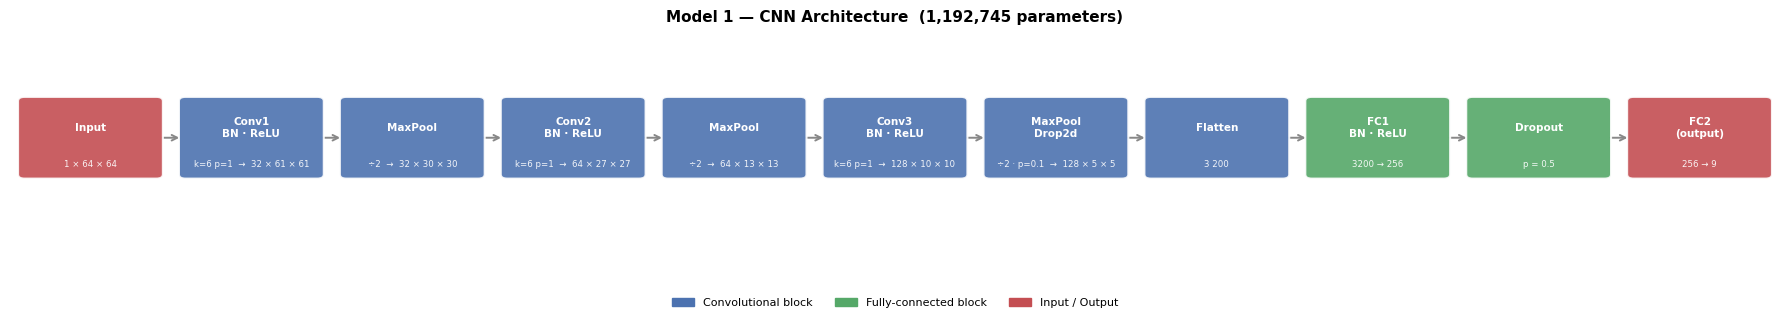

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

# ------------------------------------------------------------------
# Layer definitions  (label, sublabel, color)
# ------------------------------------------------------------------
CONV  = '#4C72B0'   # blue   — conv blocks
FC    = '#55A868'   # green  — fully-connected
SPEC  = '#C44E52'   # red    — special (input / output)

blocks = [
    # label               sub-label (dims / params)        color
    ('Input',             '1 × 64 × 64',                   SPEC),
    ('Conv1\nBN · ReLU',  'k=6 p=1  →  32 × 61 × 61',    CONV),
    ('MaxPool',           '÷2  →  32 × 30 × 30',           CONV),
    ('Conv2\nBN · ReLU',  'k=6 p=1  →  64 × 27 × 27',    CONV),
    ('MaxPool',           '÷2  →  64 × 13 × 13',           CONV),
    ('Conv3\nBN · ReLU',  'k=6 p=1  →  128 × 10 × 10',   CONV),
    ('MaxPool\nDrop2d',   '÷2 · p=0.1  →  128 × 5 × 5',  CONV),
    ('Flatten',           '3 200',                          CONV),
    ('FC1\nBN · ReLU',    '3200 → 256',                    FC),
    ('Dropout',           'p = 0.5',                        FC),
    ('FC2\n(output)',      '256 → 9',                       SPEC),
]

fig, ax = plt.subplots(figsize=(18, 3.6))
ax.set_xlim(-0.5, len(blocks) - 0.5)
ax.set_ylim(-1, 1)
ax.axis('off')

BOX_W, BOX_H = 0.82, 0.72

for i, (label, sub, color) in enumerate(blocks):
    x = i
    rect = mpatches.FancyBboxPatch(
        (x - BOX_W / 2, -BOX_H / 2), BOX_W, BOX_H,
        boxstyle='round,pad=0.04',
        facecolor=color, edgecolor='white', linewidth=1.5, alpha=0.90,
        zorder=3,
    )
    ax.add_patch(rect)
    ax.text(x, 0.10, label, ha='center', va='center',
            fontsize=7.5, fontweight='bold', color='white', zorder=4,
            multialignment='center')
    ax.text(x, -0.26, sub, ha='center', va='center',
            fontsize=6.2, color='white', alpha=0.92, zorder=4,
            multialignment='center')

    if i < len(blocks) - 1:
        ax.annotate('', xy=(i + 1 - BOX_W / 2 - 0.02, 0),
                    xytext=(i + BOX_W / 2 + 0.02, 0),
                    arrowprops=dict(arrowstyle='->', color='#888888',
                                   lw=1.4), zorder=2)

# Legend
legend_items = [
    mpatches.Patch(color=CONV,  label='Convolutional block'),
    mpatches.Patch(color=FC,    label='Fully-connected block'),
    mpatches.Patch(color=SPEC,  label='Input / Output'),
]
ax.legend(handles=legend_items, loc='lower center',
          bbox_to_anchor=(0.5, -0.38), ncol=3, frameon=False, fontsize=8)

ax.set_title('Model 1 — CNN Architecture  (1,192,745 parameters)', fontsize=11,
             fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

## 7. Train Model 1

In [8]:
import time

EPOCHS = 15
LR     = 1e-3

# Build the model + optimizer here, alongside the training loop. This couples them
# so that re-running the model-definition cell (cell 6) cannot silently wipe a trained
# `model1` and leave the test-eval cell evaluating random weights. To retrain from
# scratch, re-run *this* cell.
model1 = Model1(num_classes=NUM_CLASSES).to(device)

# Forward-pass sanity check
with torch.no_grad():
    out = model1(xb.to(device))
print(f"forward output: {tuple(out.shape)}  (expected ({BATCH_SIZE}, {NUM_CLASSES}))")

optimizer = torch.optim.Adam(model1.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()


def run_epoch(model, loader, train: bool):
    model.train(train)
    total_loss = 0.0
    total_correct = 0
    total_seen = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss    += loss.item() * yb.size(0)
            total_correct += (logits.argmax(1) == yb).sum().item()
            total_seen    += yb.size(0)
    return total_loss / total_seen, total_correct / total_seen


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model1, train_loader, train=True)
    va_loss, va_acc = run_epoch(model1, val_loader,   train=False)
    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss);   history['val_acc'].append(va_acc)
    print(f"epoch {epoch:2d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f} | "
          f"{time.time()-t0:.1f}s")


forward output: (64, 9)  (expected (64, 9))
epoch  1 | train loss 0.3947 acc 0.8543 | val loss 0.2131 acc 0.9403 | 39.6s
epoch  2 | train loss 0.1916 acc 0.9320 | val loss 0.2411 acc 0.9234 | 38.2s
epoch  3 | train loss 0.1250 acc 0.9560 | val loss 0.1515 acc 0.9547 | 38.4s
epoch  4 | train loss 0.0898 acc 0.9681 | val loss 0.1139 acc 0.9654 | 38.7s
epoch  5 | train loss 0.0675 acc 0.9761 | val loss 0.3594 acc 0.8948 | 38.2s
epoch  6 | train loss 0.0535 acc 0.9813 | val loss 0.1874 acc 0.9477 | 39.0s
epoch  7 | train loss 0.0441 acc 0.9845 | val loss 0.1889 acc 0.9481 | 39.4s
epoch  8 | train loss 0.0390 acc 0.9864 | val loss 0.1472 acc 0.9685 | 39.3s
epoch  9 | train loss 0.0342 acc 0.9882 | val loss 0.1601 acc 0.9643 | 39.4s
epoch 10 | train loss 0.0297 acc 0.9897 | val loss 0.1632 acc 0.9611 | 39.5s
epoch 11 | train loss 0.0284 acc 0.9902 | val loss 0.1593 acc 0.9619 | 39.6s
epoch 12 | train loss 0.0250 acc 0.9914 | val loss 0.1636 acc 0.9692 | 39.4s
epoch 13 | train loss 0.0228 acc

## 8. Evaluate Model 1 on the test set

In [9]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, cohen_kappa_score,
)


@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    ys, ps = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        ps.append(model(xb).argmax(1).cpu().numpy())
        ys.append(yb.numpy())
    return np.concatenate(ys), np.concatenate(ps)


y_true, y_pred = collect_predictions(model1, test_loader)
target_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(f"Test samples: {len(y_true):,}")
print(f"\nAccuracy:           {accuracy_score(y_true, y_pred):.4f}")
print(f"Balanced accuracy:  {balanced_accuracy_score(y_true, y_pred):.4f}  (mean per-class recall)")
print(f"Cohen's kappa:      {cohen_kappa_score(y_true, y_pred):.4f}")
for avg in ('macro', 'weighted'):
    p = precision_score(y_true, y_pred, average=avg, zero_division=0)
    r = recall_score(   y_true, y_pred, average=avg, zero_division=0)
    f = f1_score(       y_true, y_pred, average=avg, zero_division=0)
    print(f"{avg:>8s}: precision {p:.4f}  recall {r:.4f}  f1 {f:.4f}")

print("\nPer-class report:")
print(classification_report(y_true, y_pred, target_names=target_names,
                            digits=4, zero_division=0))

# Confusion matrix as a labeled DataFrame (rows = true, columns = predicted)
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)
print("Confusion matrix (rows=true, cols=predicted):")
cm_df

Test samples: 34,590

Accuracy:           0.9605
Balanced accuracy:  0.8827  (mean per-class recall)
Cohen's kappa:      0.8604
   macro: precision 0.8111  recall 0.8827  f1 0.8433
weighted: precision 0.9656  recall 0.9605  f1 0.9624

Per-class report:
              precision    recall  f1-score   support

      Center     0.8766    0.9430    0.9086       859
       Donut     0.8017    0.8739    0.8362       111
    Edge-Loc     0.6814    0.8449    0.7544      1038
   Edge-Ring     0.9497    0.9752    0.9623      1936
         Loc     0.6181    0.7437    0.6751       718
   Near-full     0.9643    0.9000    0.9310        30
      Random     0.8214    0.9306    0.8726       173
     Scratch     0.5948    0.7615    0.6679       239
        none     0.9921    0.9716    0.9818     29486

    accuracy                         0.9605     34590
   macro avg     0.8111    0.8827    0.8433     34590
weighted avg     0.9656    0.9605    0.9624     34590

Confusion matrix (rows=true, cols=predicte

,Center,Donut,Edge-Loc,Edge-Ring,Loc,Near-full,Random,Scratch,none
Center,810,4,2,0,12,0,0,2,29
Donut,3,97,0,0,8,0,0,0,3
Edge-Loc,4,1,877,24,49,0,5,4,74
Edge-Ring,2,1,31,1888,2,0,3,0,9
Loc,22,13,41,0,534,0,2,26,80
Near-full,1,0,0,0,0,27,2,0,0
Random,2,2,1,1,4,1,161,1,0
Scratch,0,2,11,0,11,0,1,182,32
none,80,1,324,75,244,0,22,91,28649
